## How Fluxion Composes Latency Percentiles

Fluxion (Liang et al., "On Modular Learning of Distributed Systems for Predicting End-to-End Latency", NSDI 2023) is
the closest related approach to the method of `method_v2.ipynb`, where it is the baseline of Section 7e. This notebook
shows, one step at a time, what the Fluxion-style baseline learns and how its models are composed, on the same
synthetic pipeline and with the same functions as `method_v2`:

- `simulate_chain` and `quantile_with_lower_bound` from `snc_bounds.py` (simulated pipeline, measured quantile),
- `fluxion_training_rows` and `train_fluxion_chain` from `baselines.py` (training rows, models, composition).

**The idea in one paragraph.** Fluxion does not derive the latency of a composition from the latencies of its
services. It *measures* the composed system, reduces every measurement run to a few latency percentiles per service,
and fits one regression model per service and percentile. The inputs of a model are the configuration of its service
and the percentiles of the service it depends on. To predict a new configuration, the models are evaluated one after
the other, and each one receives the *predictions* of the one before it.

**Terms used throughout.**
- *Position* $k$: the $k$-th service of the chain. The chain cycles through the services $s_1, s_2, s_3$ of `method_v2`.
- $L_k$: the cumulative latency of an item, from entering the chain until it leaves position $k$, in seconds. It
  includes the waiting time in every queue up to position $k$.
- $Q_k(q)$: the $q$-quantile of $L_k$ over the items of one run at one configuration, in seconds; e.g. $Q_k(0.95)$ is
  the p95. The quantile levels $q$ used are `fluxion_levels` in the first cell.
- $\hat Q_k(q)$: the model's prediction of $Q_k(q)$.
- $x$: the configuration (CPU, quality, parallelism), shared by all positions as in `method_v2`.
- *Reference configuration*: the one configuration that `method_v2` uses for its single-configuration comparison
  (Section 7, `x_pipeline_cfg` there, `x_reference` here). Its values are set in the first cell. It is an arbitrary
  operating point inside the training range, not an optimum or a typical setting; wherever a figure shows one
  configuration only, it is this one.

The sections follow the steps of the approach:

1. A benchmark run and its percentiles
2. The training rows
3. The percentile regressions
4. Composition: evaluating the models along the chain
5. Where the prediction error comes from: measured vs. predicted upstream percentiles
6. Accurate on average is not a guarantee

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.patches import FancyBboxPatch

# the functions of method_v2: simulated pipeline and measured quantile (snc_bounds.py), Fluxion-style baseline (baselines.py)
from snc_bounds import quantile_with_lower_bound, simulate_chain
from baselines import fluxion_training_rows, train_fluxion_chain

# Workload and target quantile, with the values of method_v2
alpha = 0.05              # epsilon: the predicted quantile is the (1 - alpha) quantile
arrival_rate = 4.0        # lambda: items per second offered to the pipeline
arrival_process = "poisson"
arrival_jitter = 0.2      # only used by periodic arrivals
item_correlation = 0.7    # correlation of an item's execution-time noise across services
workload = dict(process=arrival_process, rate=arrival_rate, jitter=arrival_jitter)
arrival_name = "Poisson" if arrival_process == "poisson" else f"periodic (±{arrival_jitter:.0%} jitter)"

# Fluxion-style baseline
fluxion_levels = sorted({0.5, 0.75, 0.9, 1 - alpha})   # quantile levels passed from position to position
target = int(np.argmin(np.abs(np.array(fluxion_levels) - (1 - alpha))))   # index of the predicted level 1 - alpha
n_positions = 9           # chain depth K; the chain cycles through s1, s2, s3
n_shown = 3               # positions shown in the per-position figures
n_train = 50              # training configurations = benchmark runs
n_trace_items = 2000      # items per benchmark run
n_sim_items = 5000        # items per simulated run of the ground truth
coverage_check = dict(n_batches=10, confidence=0.95)   # confidence interval of a measured quantile, as in method_v2 (6f)

# The synthetic system of method_v2 (Section 1): three services and their true mean execution time
service_names = ["s1", "s2", "s3"]
service_types = ["type_A", "type_B", "type_C"]
noise_levels = {"s1": 0.0060, "s2": 0.0010, "s3": 0.0035}   # std of the execution-time noise per service (s)
path = [service_names[k % 3] for k in range(n_positions)]
path_types = [service_types[k % 3] for k in range(n_positions)]
x_reference = np.array([[1.0, 1.0, 2.0]])                      # [CPU, quality, parallelism], the reference configuration of method_v2

level_name = lambda q: f"p{round(q * 100, 6):g}"
level_names = [level_name(q) for q in fluxion_levels]
level_colors = dict(zip(level_names, ["tab:blue", "tab:green", "tab:orange", "tab:red", "tab:purple"]))
target_name = level_names[target]
pct = lambda value: f"{value:.0%}"
ms = lambda value: f"{value * 1000:.0f} ms"


def true_demand(x, service_type):
    # mean execution time (s) of a service at the configurations x; copy of method_v2, Section 1a
    cpu, quality, parallelism = x[:, 0], x[:, 1], x[:, 2]
    if service_type == "type_A":
        return 0.010 + 0.040 / cpu + 0.030 * (quality ** 2.0)
    elif service_type == "type_B":
        return 0.012 + 0.035 / cpu + 0.025 * (quality ** 1.5)
    else:
        return 0.008 + 0.030 / cpu + 0.020 * (quality ** 1.8)


def simulate_cumulative(x_cfgs, n_items, rng):
    # cumulative latencies L_k (configurations, items, positions) of the simulated chain (simulate_chain in snc_bounds.py)
    x_cfgs = np.atleast_2d(x_cfgs)
    mean_execution = np.column_stack([true_demand(x_cfgs, s_type) for s_type in path_types])
    node_latencies, _ = simulate_chain(mean_execution, [noise_levels[s] for s in path], n_items=n_items,
                                       item_correlation=item_correlation, rng=rng, **workload)
    return node_latencies, np.cumsum(node_latencies, axis=2)


def measured_quantiles(cumulative):
    # Q_k(q) for every configuration: (configurations, levels, positions)
    return np.moveaxis(np.quantile(cumulative, fluxion_levels, axis=1), 0, 1)


# Training configurations: the same draws as method_v2, Section 1a (its global seed)
draws = np.random.RandomState(35)
X_train = np.column_stack([draws.uniform(0.5, 2.0, n_train), draws.uniform(0.5, 2.0, n_train), draws.uniform(1.0, 4.0, n_train)])
print(f"Chain of {n_positions} positions: {' → '.join(path)}; quantile levels: {', '.join(level_names)}; predicted: {target_name}")

Chain of 9 positions: s1 → s2 → s3 → s1 → s2 → s3 → s1 → s2 → s3; quantile levels: p50, p75, p90, p95; predicted: p95


## 1. A Benchmark Run and Its Percentiles

Fluxion's training data comes from *benchmarks*: the composed system runs at one configuration for a while, and every
service logs the latency of every request. Here, one benchmark is one simulated run of the whole chain at one training
configuration (`n_trace_items` items; the first 10% are dropped as warm-up by `simulate_chain`). There is one run per
training configuration.

Note what is *not* used: the single-service execution-time measurements that the GPs of `method_v2` are trained on.
Fluxion only ever sees the latencies of the composed chain, which already contain the queueing.

**The figure** shows one of these runs, the training configuration closest to the reference one. Each panel is one
position of the chain; the horizontal axis is the cumulative latency $L_k$ of an item (s), the vertical axis the number
of items. The vertical lines are the quantiles $Q_k(q)$ of the run. These few numbers per position are all that is
kept of the run.

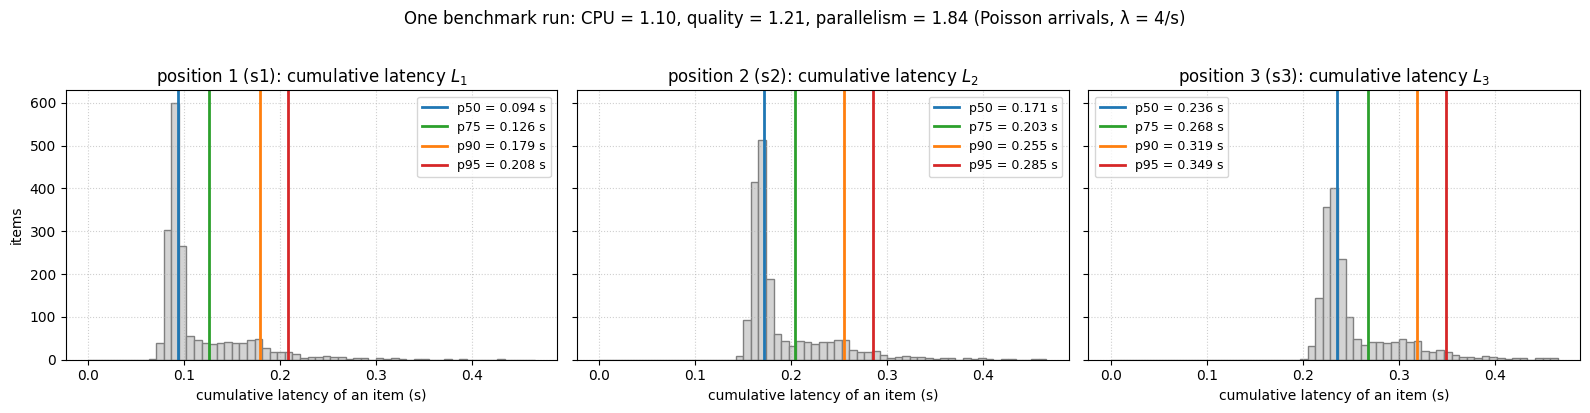

**What this shows.** The run has 1800 items after warm-up. For every position it is reduced to 4 numbers; for position 3 these are p50 = 0.236 s, p75 = 0.268 s, p90 = 0.319 s, p95 = 0.349 s. The distributions have a long right tail (items that had to wait), so the p95 lies far from the median: 2.21× the p50 at position 1.

In [2]:
rng_traces = np.random.default_rng(2026)
trace_node_latencies, trace_cumulative = simulate_cumulative(X_train, n_trace_items, rng_traces)
trace_quantiles = measured_quantiles(trace_cumulative)   # (configurations, levels, positions)

example = int(np.argmin(np.linalg.norm(X_train - x_reference, axis=1)))   # training configuration closest to the reference one
fig, axes = plt.subplots(1, n_shown, figsize=(16, 4), sharex=True, sharey=True)
bins = np.linspace(0, np.quantile(trace_cumulative[example, :, n_shown - 1], 0.995), 60)
for k, ax in enumerate(axes):
    ax.hist(trace_cumulative[example, :, k], bins=bins, color="lightgray", edgecolor="gray")
    for j, name in enumerate(level_names):
        ax.axvline(trace_quantiles[example, j, k], color=level_colors[name], linewidth=2,
                   label=f"{name} = {trace_quantiles[example, j, k]:.3f} s")
    ax.set_title(f"position {k + 1} ({path[k]}): cumulative latency $L_{k + 1}$")
    ax.set_xlabel("cumulative latency of an item (s)")
    ax.legend(fontsize=9)
    ax.grid(True, linestyle=":", alpha=0.6)
axes[0].set_ylabel("items")
plt.suptitle(f"One benchmark run: CPU = {X_train[example, 0]:.2f}, quality = {X_train[example, 1]:.2f}, parallelism = {X_train[example, 2]:.2f} "
             f"({arrival_name} arrivals, λ = {arrival_rate:g}/s)", y=1.02)
plt.tight_layout()
plt.show()

display(Markdown(
    f"**What this shows.** The run has {trace_cumulative.shape[1]} items after warm-up. For every position it is reduced to "
    f"{len(fluxion_levels)} numbers; for position {n_shown} these are "
    + ", ".join(f"{name} = {trace_quantiles[example, j, n_shown - 1]:.3f} s" for j, name in enumerate(level_names))
    + f". The distributions have a long right tail (items that had to wait), so the {target_name} lies far from the median: "
    f"{trace_quantiles[example, target, 0] / trace_quantiles[example, 0, 0]:.2f}× the {level_names[0]} at position 1."))

## 2. The Training Rows

`fluxion_training_rows` turns the runs into one table per position, with one row per run:

- **inputs:** the configuration $x$ of the run and the quantiles $Q_{k-1}(q)$ of the position before, at all levels.
  Position 1 has no position before it and takes $x$ only.
- **targets:** the quantiles $Q_k(q)$ of this position, one column per level.

The upstream quantiles in a training row are the *measured* ones of the same run. The table below shows the first rows
of position 2.

In [3]:
rows = fluxion_training_rows(X_train, trace_node_latencies, fluxion_levels)

inputs, targets = rows[1]   # position 2
table = pd.DataFrame(np.column_stack([inputs, targets]),
                     columns=["x: CPU", "x: quality", "x: parallelism"] + [f"input: {name} of $L_1$ (s)" for name in level_names]
                             + [f"target: {name} of $L_2$ (s)" for name in level_names])
display(table.head(5).round(3))
print(f"{len(rows)} positions; per position {inputs.shape[0]} rows, {inputs.shape[1]} inputs ({rows[0][0].shape[1]} at position 1) and {targets.shape[1]} targets")

,x: CPU,x: quality,x: parallelism,input: p50 of $L_1$ (s),input: p75 of $L_1$ (s),input: p90 of $L_1$ (s),input: p95 of $L_1$ (s),target: p50 of $L_2$ (s),target: p75 of $L_2$ (s),target: p90 of $L_2$ (s),target: p95 of $L_2$ (s)
0,1.187,1.703,2.112,0.141,0.239,0.329,0.398,0.239,0.336,0.426,0.495
1,0.963,1.406,2.487,0.117,0.179,0.241,0.290,0.208,0.270,0.330,0.381
2,0.847,1.240,2.145,0.108,0.147,0.202,0.248,0.196,0.235,0.290,0.335
3,0.916,1.900,1.097,0.257,0.384,0.553,0.672,0.372,0.500,0.668,0.788
4,1.726,1.480,2.353,0.104,0.151,0.198,0.247,0.181,0.228,0.276,0.323


9 positions; per position 50 rows, 7 inputs (3 at position 1) and 4 targets


## 3. The Percentile Regressions

`train_fluxion_chain` fits one Gaussian Process per position and per quantile level (a "learning assignment" in
Fluxion's terms), each on its own column of targets. The model is the GP of `service_gp.py` with a Matérn 5/2 kernel,
the kernel Fluxion's evaluation uses. A quantile is an ordinary regression target here: the fit minimizes the distance
to the measured quantile, and an error above the target counts the same as an error below it.

### 3a. Why the upstream percentile is a useful input

**The figure** shows the training rows of positions 2 and 3: the horizontal axis is the measured upstream
$Q_{k-1}$ at the predicted level (s), the vertical axis the measured $Q_k$ at the same level (s); one point is one
benchmark run, colored by its CPU allocation. The black line is "no latency added" ($Q_k = Q_{k-1}$). The vertical
distance of a point above that line is what position $k$ adds to the tail.

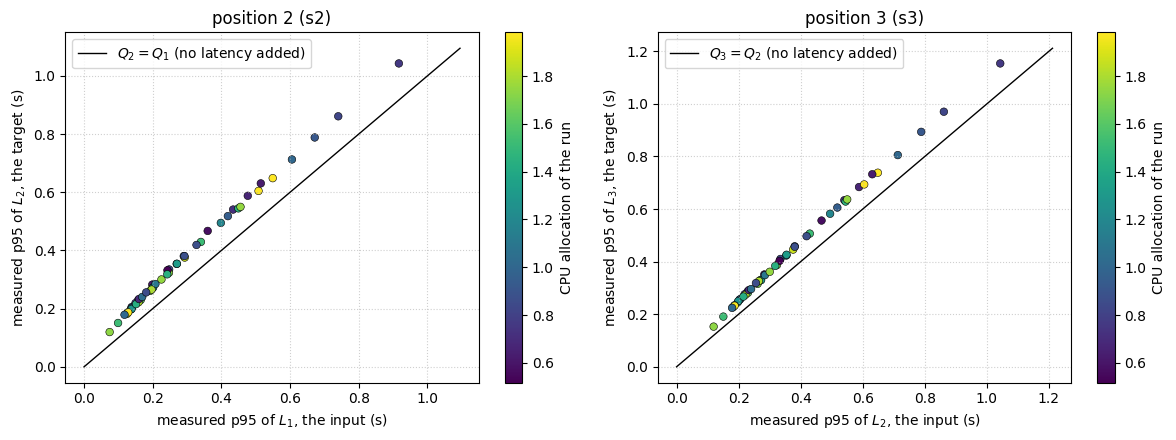

**What this shows.** The upstream p95 and the p95 of the next position rise together (Spearman rank correlation 1.00 to 1.00 over the 50 runs): most of $L_k$ *is* $L_{k-1}$, so the upstream quantile carries most of the information about the target. What is left for the model to learn is the distance above the black line, which is between 33 ms and 126 ms over these runs and positions and depends on the configuration; that is why the model receives both $x$ and the upstream quantiles.

In [4]:
fluxion = train_fluxion_chain(rows, fluxion_levels)

fig, axes = plt.subplots(1, n_shown - 1, figsize=(12, 4.5))
for k, ax in zip(range(1, n_shown), axes):
    upstream, own = trace_quantiles[:, target, k - 1], trace_quantiles[:, target, k]
    points = ax.scatter(upstream, own, c=X_train[:, 0], cmap="viridis", s=30, edgecolor="black", linewidth=0.4)
    limits = [0, max(own.max(), upstream.max()) * 1.05]
    ax.plot(limits, limits, color="black", linewidth=1, label=f"$Q_{k + 1} = Q_{k}$ (no latency added)")
    ax.set_xlabel(f"measured {target_name} of $L_{k}$, the input (s)")
    ax.set_ylabel(f"measured {target_name} of $L_{k + 1}$, the target (s)")
    ax.set_title(f"position {k + 1} ({path[k]})")
    ax.legend(loc="upper left")
    ax.grid(True, linestyle=":", alpha=0.6)
    fig.colorbar(points, ax=ax, label="CPU allocation of the run")
plt.tight_layout()
plt.show()

rank_correlation = [pd.Series(trace_quantiles[:, target, k - 1]).corr(pd.Series(trace_quantiles[:, target, k]), method="spearman") for k in range(1, n_shown)]
added = trace_quantiles[:, target, 1:n_shown] - trace_quantiles[:, target, :n_shown - 1]   # what positions 2.. add to the predicted level
display(Markdown(
    f"**What this shows.** The upstream {target_name} and the {target_name} of the next position rise together (Spearman rank "
    f"correlation {min(rank_correlation):.2f} to {max(rank_correlation):.2f} over the {n_train} runs): most of $L_k$ *is* $L_{{k-1}}$, "
    "so the upstream quantile carries most of the information about the target. What is left for the model to learn is the "
    f"distance above the black line, which is between {ms(added.min())} and {ms(added.max())} over these runs and positions and depends "
    "on the configuration; that is why the model receives both $x$ and the upstream quantiles."))

### 3b. The fitted regressions along the CPU axis

**The figure** shows the fitted models of the first positions as a function of the CPU allocation, with quality and
parallelism fixed at the reference configuration. The horizontal axis is the CPU allocation, the vertical axis the
cumulative latency (s). One color is one quantile level. A solid line is the model's prediction $\hat Q_k(q)$, obtained
by evaluating the chain up to position $k$ (`FluxionChain.quantiles`); the dots are the quantiles measured in a fresh
simulation of the same configurations, which the models have not seen. The training runs are not shown, because they
lie at other values of quality and parallelism.

Look at how closely the solid lines follow the dots, and whether the agreement gets worse from the left panel to the
right one, where the inputs of the models are themselves predictions.

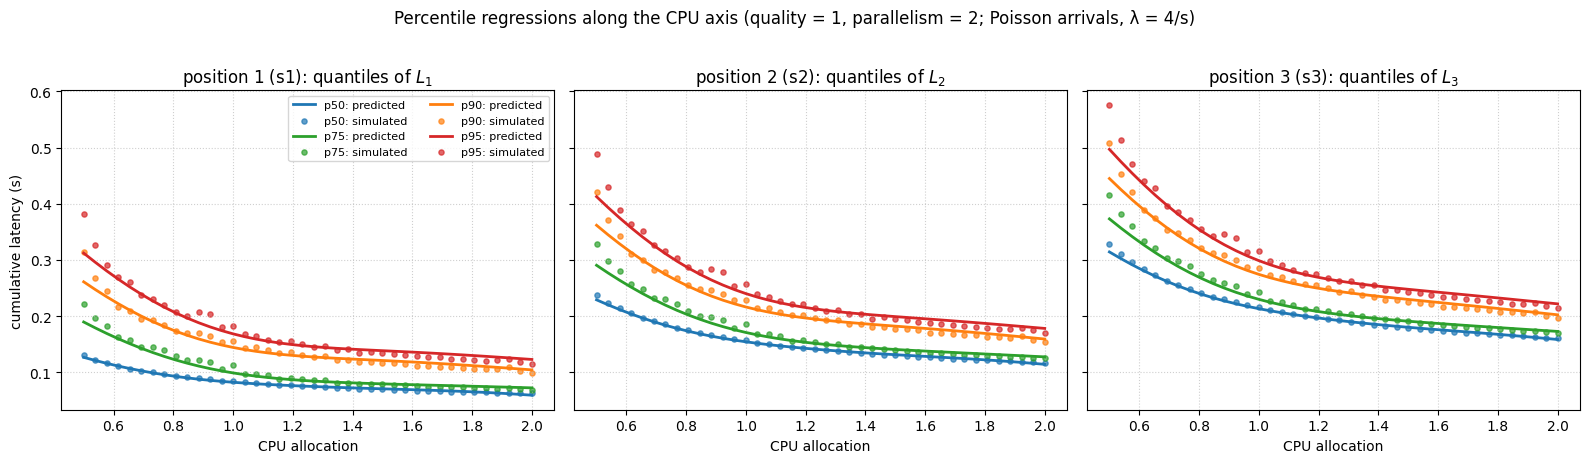

**What this shows.** Along this slice, the median relative error of the predicted p95 is 3.5% at position 1, 2.8% at position 2, 2.3% at position 3. The upper quantiles spread apart at low CPU, where the services are slow and the queues long; the models reproduce this because the training runs contained it. The simulated dots scatter around the lines: a quantile measured from 5000 items is itself noisy, most at the upper levels.

In [5]:
n_slice = 40
X_slice = np.column_stack([np.linspace(0.5, 2.0, n_slice), np.full(n_slice, x_reference[0, 1]), np.full(n_slice, x_reference[0, 2])])
rng_slice = np.random.default_rng(3)
slice_quantiles = measured_quantiles(simulate_cumulative(X_slice, n_sim_items, rng_slice)[1])

fig, axes = plt.subplots(1, n_shown, figsize=(16, 4.5), sharey=True)
for k, ax in enumerate(axes):
    predicted = fluxion.quantiles(X_slice, k + 1)   # (configurations, levels)
    for j, name in enumerate(level_names):
        ax.plot(X_slice[:, 0], predicted[:, j], color=level_colors[name], linewidth=2, label=f"{name}: predicted")
        ax.scatter(X_slice[:, 0], slice_quantiles[:, j, k], color=level_colors[name], s=14, alpha=0.7, label=f"{name}: simulated")
    ax.set_title(f"position {k + 1} ({path[k]}): quantiles of $L_{k + 1}$")
    ax.set_xlabel("CPU allocation")
    ax.grid(True, linestyle=":", alpha=0.6)
axes[0].set_ylabel("cumulative latency (s)")
axes[0].legend(fontsize=8, ncol=2)
plt.suptitle(f"Percentile regressions along the CPU axis (quality = {x_reference[0, 1]:g}, parallelism = {x_reference[0, 2]:g}; "
             f"{arrival_name} arrivals, λ = {arrival_rate:g}/s)", y=1.02)
plt.tight_layout()
plt.show()

slice_error = [np.median(np.abs(fluxion.quantiles(X_slice, k + 1)[:, target] / slice_quantiles[:, target, k] - 1)) for k in range(n_shown)]
display(Markdown(
    f"**What this shows.** Along this slice, the median relative error of the predicted {target_name} is "
    + ", ".join(f"{error:.1%} at position {k + 1}" for k, error in enumerate(slice_error))
    + ". The upper quantiles spread apart at low CPU, where the services are slow and the queues long; the models "
    "reproduce this because the training runs contained it. The simulated dots scatter around the lines: a quantile "
    f"measured from {n_sim_items} items is itself noisy, most at the upper levels."))

## 4. Composition: Evaluating the Models Along the Chain

To predict a configuration that was never run, the models are evaluated in the order of the chain
(`FluxionChain.quantiles`):

1. Position 1 predicts its quantiles $\hat Q_1$ from the configuration $x$.
2. Position 2 predicts $\hat Q_2$ from $x$ and $\hat Q_1$. In training this input was a measured $Q_1$; now it is a
   prediction.
3. Every further position does the same with the predictions of the position before it.
4. The end-to-end prediction is the entry of the last $\hat Q_K$ at the level $1-\varepsilon$.

The cell below performs these steps by hand for the reference configuration, checks that the result equals
`FluxionChain.quantiles`, and simulates the reference configuration as the ground truth.

**The diagram** shows the first positions: every box holds the models of one position, the arrows from below carry
the configuration, and the arrows between the boxes carry the predicted quantiles, labeled with the predicted value at
the reference configuration.

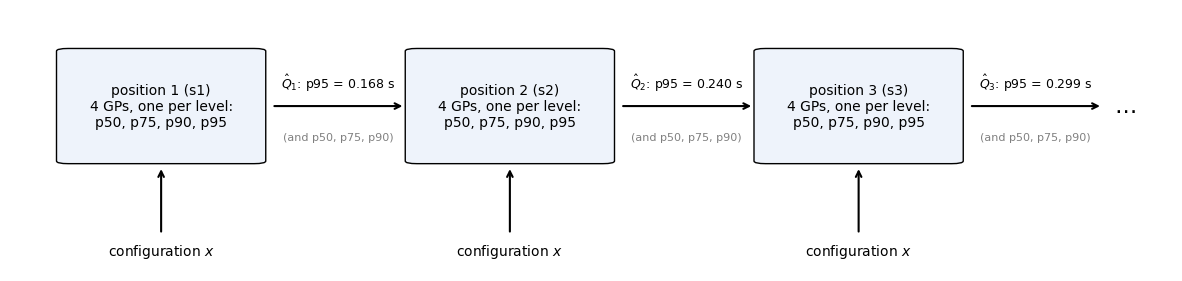

p50                         p75                \
         predicted (s) simulated (s) predicted (s) simulated (s)   
position                                                           
1 (s1)           0.082         0.083         0.099         0.104   
2 (s2)           0.154         0.156         0.171         0.177   
3 (s3)           0.213         0.215         0.230         0.235   
4 (s1)           0.295         0.298         0.316         0.322   
5 (s2)           0.367         0.370         0.388         0.395   
6 (s3)           0.426         0.429         0.448         0.454   
7 (s1)           0.508         0.512         0.534         0.541   
8 (s2)           0.580         0.584         0.606         0.614   
9 (s3)           0.638         0.643         0.666         0.673   

                   p90                         p95                
         predicted (s) simulated (s) predicted (s) simulated (s)  
position                                                          
1 (s1)           0.144         0.150         0.168         0.176  
2 (s2)           0.216         0.223         0.240         0.248  
3 (s3)           0.274         0.281         0.299         0.307  
4 (s1)           0.360         0.368         0.387         0.396  
5 (s2)           0.433         0.440         0.459         0.468  
6 (s3)           0.491         0.499         0.517         0.527  
7 (s1)           0.577         0.586         0.606         0.616  
8 (s2)           0.649         0.658         0.678         0.688  
9 (s3)           0.707         0.717         0.736         0.747

In [6]:
# Traversal by hand at the reference configuration
upstream, predicted_steps = None, []
for models in fluxion.assignments:
    model_inputs = x_reference if upstream is None else np.column_stack([x_reference, upstream])
    upstream = np.column_stack([model.predict(model_inputs) for model in models])   # predicted quantiles of this position
    predicted_steps.append(upstream[0])
predicted_steps = np.array(predicted_steps)   # (positions, levels)
assert np.allclose(predicted_steps[-1], fluxion.quantiles(x_reference, n_positions)[0])

# Ground truth: the reference configuration simulated in several replications, pooled
rng_reference = np.random.default_rng(42)
reference_node_latencies, reference_cumulative = simulate_cumulative(np.repeat(x_reference, 20, axis=0), n_sim_items, rng_reference)
reference_quantiles = np.quantile(reference_cumulative.reshape(-1, n_positions), fluxion_levels, axis=0).T   # (positions, levels)

fig, ax = plt.subplots(figsize=(15, 3.4))
ax.axis("off")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
arrow = dict(arrowstyle="->", linewidth=1.5)
for k in range(n_shown):
    left = 0.05 + 0.30 * k
    ax.add_patch(FancyBboxPatch((left, 0.42), 0.16, 0.42, boxstyle="round,pad=0.01", facecolor="#eef3fb", edgecolor="black"))
    ax.text(left + 0.08, 0.63, f"position {k + 1} ({path[k]})\n{len(level_names)} GPs, one per level:\n{', '.join(level_names)}", ha="center", va="center", fontsize=10)
    ax.annotate("", xy=(left + 0.08, 0.40), xytext=(left + 0.08, 0.14), arrowprops=arrow)
    ax.text(left + 0.08, 0.06, "configuration $x$", ha="center", fontsize=10)
    ax.annotate("", xy=(left + 0.29, 0.63), xytext=(left + 0.175, 0.63), arrowprops=arrow)
    ax.text(left + 0.232, 0.70, f"$\\hat Q_{k + 1}$: {target_name} = {predicted_steps[k, target]:.3f} s", ha="center", fontsize=9)
    ax.text(left + 0.232, 0.50, f"(and {', '.join(level_names[:target] + level_names[target + 1:])})", ha="center", fontsize=8, color="gray")
ax.text(0.05 + 0.30 * n_shown, 0.63, "…" if n_shown < n_positions else "", fontsize=16, va="center")
plt.show()

comparison = pd.DataFrame({(name, kind): values[:, j] for j, name in enumerate(level_names)
                           for kind, values in (("predicted (s)", predicted_steps), ("simulated (s)", reference_quantiles))},
                          index=pd.Index([f"{k + 1} ({path[k]})" for k in range(n_positions)], name="position"))
display(comparison.round(3))

### 4a. The predicted quantiles along the chain

**The figure** shows the numbers of the table above. The horizontal axis is the position in the chain, the vertical
axis the cumulative latency (s). One color is one quantile level; the solid line with dots is the prediction passed from
position to position, the dashed line with crosses the quantile of the simulated reference configuration. The rightmost
points of the top level are the end-to-end prediction and its ground truth.

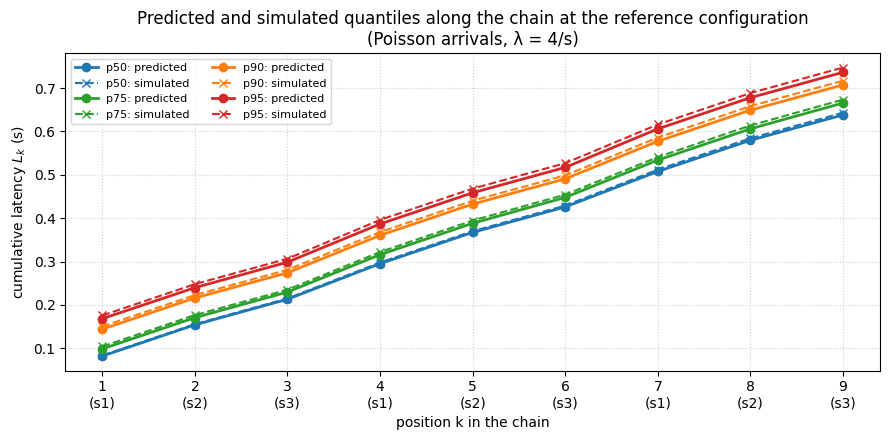

**What this shows** (reference configuration only). The predicted p95 after 9 positions is 0.736 s, the simulated one 0.747 s (-1.5%). Along the chain, the relative error of the predicted p95 lies between -4.2% and -1.5%.

**Why the quantiles are learned and not added.** Adding the simulated p95 latencies of the 9 single positions gives 0.780 s, 1.04× the simulated p95 of the end-to-end latency (0.747 s): an item is rarely in the tail of every position at once, so quantiles of a sum are not sums of quantiles. The end-to-end quantile cannot be computed from the quantiles of the single positions; the models have learned its growth from position to position from the runs. A single configuration cannot show how reliable the prediction is; Sections 5 and 6 use many held-out configurations.

In [7]:
positions = np.arange(1, n_positions + 1)
fig, ax = plt.subplots(figsize=(9, 4.5))
for j, name in enumerate(level_names):
    ax.plot(positions, predicted_steps[:, j], "o-", color=level_colors[name], linewidth=2, label=f"{name}: predicted")
    ax.plot(positions, reference_quantiles[:, j], "x--", color=level_colors[name], linewidth=1.5, label=f"{name}: simulated")
ax.set_xticks(positions, [f"{k}\n({path[k - 1]})" for k in positions])
ax.set_xlabel("position k in the chain")
ax.set_ylabel("cumulative latency $L_k$ (s)")
ax.set_title(f"Predicted and simulated quantiles along the chain at the reference configuration\n({arrival_name} arrivals, λ = {arrival_rate:g}/s)")
ax.legend(fontsize=8, ncol=2)
ax.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

reference_error = predicted_steps[:, target] / reference_quantiles[:, target] - 1
# the quantile of every position's own latency (not cumulative), added up over the chain
sum_of_node_quantiles = np.quantile(reference_node_latencies.reshape(-1, n_positions), 1 - alpha, axis=0).sum()
display(Markdown(
    f"**What this shows** (reference configuration only). The predicted {target_name} after {n_positions} positions is "
    f"{predicted_steps[-1, target]:.3f} s, the simulated one {reference_quantiles[-1, target]:.3f} s "
    f"({reference_error[-1]:+.1%}). Along the chain, the relative error of the predicted {target_name} lies between "
    f"{reference_error.min():+.1%} and {reference_error.max():+.1%}.\n\n"
    f"**Why the quantiles are learned and not added.** Adding the simulated {target_name} latencies of the {n_positions} single positions "
    f"gives {sum_of_node_quantiles:.3f} s, {sum_of_node_quantiles / reference_quantiles[-1, target]:.2f}× the simulated {target_name} of the "
    f"end-to-end latency ({reference_quantiles[-1, target]:.3f} s): an item is rarely in the tail of every position at once, so quantiles "
    "of a sum are not sums of quantiles. The end-to-end quantile cannot be computed from the quantiles of the single positions; "
    "the models have learned its growth from position to position from the runs. "
    "A single configuration cannot show how reliable the prediction is; Sections 5 and 6 use many held-out configurations."))

### 4b. What a position does with its upstream input

The models are black boxes, but their reaction to the upstream input can be probed. At the reference configuration, the
input $\hat Q_1$ of position 2 is scaled up and down as a whole (all levels by the same factor), and the predicted
$\hat Q_2(1-\varepsilon)$ is recorded.

**The figure** shows the result: the horizontal axis is the upstream quantile at the predicted level that is fed into
the model (s), the vertical axis
the model's prediction for position 2 (s). Both axes have the same range and scale. The dot is the unscaled input, i.e. the value used in the composition. The
dashed line has slope 1 through that dot and therefore runs at 45°: it is the response of a model that simply adds a fixed amount to the upstream
quantile. The shaded band is the range of upstream values that occurred in the training runs; the curve is probed
from below to above that range, and outside the band the model extrapolates. The band only describes this one input:
a large upstream value combined with the fast reference configuration did not occur in the training runs either, so
the right part of the band is also far from the data.

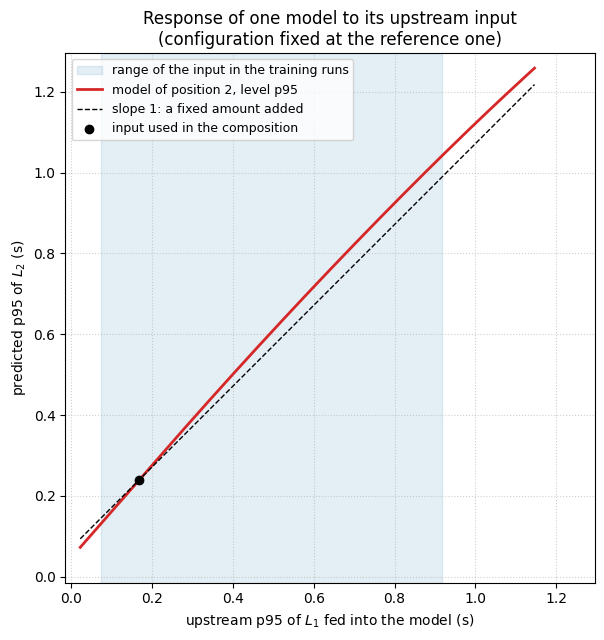

**What this shows.** At the input used in the composition, the prediction changes by 1.14 s per second of upstream p95. A slope of 1 would mean that the position adds the same amount to the tail whatever arrives from upstream. The slope is above 1: in the training runs, a longer upstream tail went together with more latency added at this position (a slow configuration is slow at every position), and the model has learned that relation. This slope is also the factor by which an *error* of the upstream prediction is passed on to this position. Outside the shaded range (0.07 s to 0.92 s in the training runs) the curve is an extrapolation and carries no information about the system.

In [8]:
probe_position = 1   # index of position 2
probe_model = fluxion.assignments[probe_position][target]
train_low, train_high = trace_quantiles[:, target, probe_position - 1].min(), trace_quantiles[:, target, probe_position - 1].max()
# scaling factors of the upstream quantiles: from below the smallest to above the largest upstream value of the training runs
scales = np.linspace(0.3 * train_low, 1.25 * train_high, 300) / predicted_steps[probe_position - 1, target]
probe_inputs = np.column_stack([np.repeat(x_reference, len(scales), axis=0), scales[:, None] * predicted_steps[probe_position - 1][None, :]])
probe_response = probe_model.predict(probe_inputs)
fed = scales * predicted_steps[probe_position - 1, target]

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.axvspan(train_low, train_high, color="tab:blue", alpha=0.12, label="range of the input in the training runs")
ax.plot(fed, probe_response, color=level_colors[target_name], linewidth=2, label=f"model of position {probe_position + 1}, level {target_name}")
base_in, base_out = predicted_steps[probe_position - 1, target], predicted_steps[probe_position, target]
ax.plot(fed, base_out + (fed - base_in), color="black", linestyle="--", linewidth=1, label="slope 1: a fixed amount added")
ax.scatter([base_in], [base_out], color="black", zorder=3, label="input used in the composition")
ax.set_xlabel(f"upstream {target_name} of $L_{probe_position}$ fed into the model (s)")
ax.set_ylabel(f"predicted {target_name} of $L_{probe_position + 1}$ (s)")
ax.set_title("Response of one model to its upstream input\n(configuration fixed at the reference one)")
# same range and scale on both axes, so that the slope-1 line runs at 45 degrees
axis_low, axis_high = min(fed.min(), probe_response.min()), max(fed.max(), probe_response.max())
axis_pad = 0.03 * (axis_high - axis_low)
ax.set_xlim(axis_low - axis_pad, axis_high + axis_pad)
ax.set_ylim(axis_low - axis_pad, axis_high + axis_pad)
ax.set_aspect("equal")
ax.legend(fontsize=9, loc="upper left")
ax.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

inside = (fed >= train_low) & (fed <= train_high)
local_slope = np.gradient(probe_response, fed)[np.argmin(np.abs(scales - 1))]
display(Markdown(
    f"**What this shows.** At the input used in the composition, the prediction changes by {local_slope:.2f} s per second of "
    f"upstream {target_name}. A slope of 1 would mean that the position adds the same amount to the tail whatever arrives from "
    "upstream. "
    + ("The slope is above 1: in the training runs, a longer upstream tail went together with more latency added at this position "
       "(a slow configuration is slow at every position), and the model has learned that relation. " if local_slope > 1 else
       "The slope is below 1: the model attributes part of the latency to the configuration $x$, which is held fixed here. ")
    + "This slope is also the factor by which an *error* of the upstream prediction is passed on to this position. Outside the shaded range "
    f"({train_low:.2f} s to {train_high:.2f} s in the training runs) the curve is an extrapolation and carries no information "
    "about the system."))

## 5. Where the Prediction Error Comes From: Measured vs. Predicted Upstream Percentiles

Each model was trained with *measured* upstream quantiles, but in the composition it receives *predicted* ones. The
error of a position therefore has two sources: the model's own error, and the error of its input. They can be
separated on held-out configurations (random draws from the training range, simulated as the ground truth) by
evaluating every model twice:

- **measured input:** the model of position $k$ receives the quantiles $Q_{k-1}$ measured in the simulation of the
  held-out configuration. This is the situation of training; it is not available for a configuration that was never run.
- **composed:** the model receives the predictions $\hat Q_{k-1}$, as in Section 4. This is the actual baseline.

**The figure** shows, for every position on the horizontal axis, the distribution over the held-out configurations of
the relative error of the predicted level $1-\varepsilon$ (prediction ÷ measured quantile − 1; 0 is exact, negative means
the prediction is too low). Each box spans the middle half of the configurations, the line inside it is the median, and the
whiskers reach the 5th and 95th percentile.

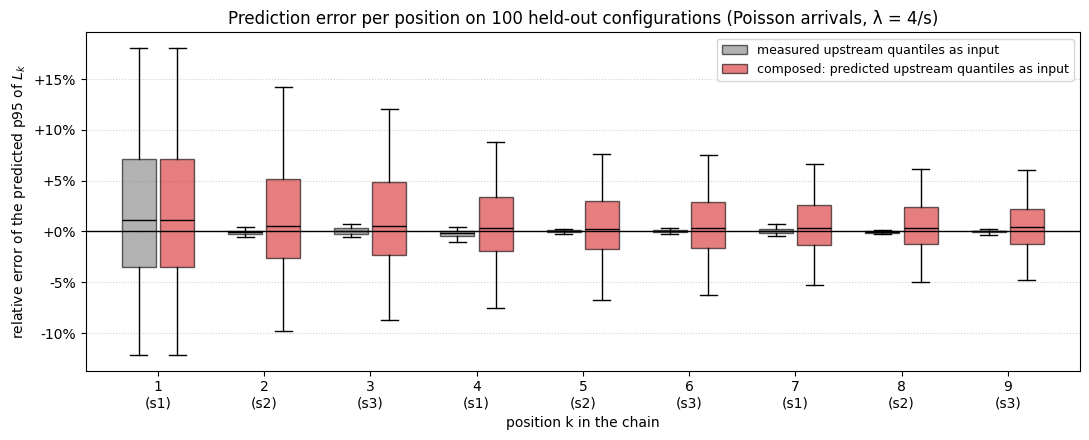

**What this shows** (Poisson arrivals, λ = 4/s, 100 held-out configurations).
- **Position 1** has no upstream input, so both variants are the same model: median absolute relative error 5.0%.
- **Position 9:** 0.1% with measured inputs and 1.9% composed. With the true upstream quantiles, a model is almost exact; nearly all of the error of the composed prediction is inherited from upstream.
- **Relative vs. absolute:** the cumulative latency grows along the chain, so the same absolute error becomes a smaller relative one. In absolute terms the median error of the composed prediction is 13 ms at position 1 and 15 ms at position 9: the error made at position 1, the only position that has to predict the queue of the external arrivals from $x$ alone, is carried through the chain.
- **Bias:** the median relative error of the composed prediction is +1.1% at position 1 and +0.4% at position 9; the boxes are spread to both sides of 0.

In [9]:
n_cfg_test = 100
rng_test = np.random.default_rng(11)
X_cfg_test = np.column_stack([rng_test.uniform(0.5, 2.0, n_cfg_test), rng_test.uniform(0.5, 2.0, n_cfg_test), rng_test.uniform(1.0, 4.0, n_cfg_test)])
test_cumulative = simulate_cumulative(X_cfg_test, n_sim_items, rng_test)[1]
test_quantiles = measured_quantiles(test_cumulative)   # (configurations, levels, positions)

composed = np.column_stack([fluxion.quantiles(X_cfg_test, k + 1)[:, target] for k in range(n_positions)])   # (configurations, positions)
with_measured_input = np.column_stack(
    [fluxion.assignments[k][target].predict(X_cfg_test if k == 0 else np.column_stack([X_cfg_test, test_quantiles[:, :, k - 1]]))
     for k in range(n_positions)])
measured = test_quantiles[:, target, :]
error_composed, error_measured_input = composed / measured - 1, with_measured_input / measured - 1

fig, ax = plt.subplots(figsize=(11, 4.5))
box_style = dict(whis=(5, 95), showfliers=False, widths=0.32, patch_artist=True, medianprops=dict(color="black"))
box_measured = ax.boxplot(error_measured_input, positions=positions - 0.18, **box_style)
box_composed = ax.boxplot(error_composed, positions=positions + 0.18, **box_style)
for boxes, color in ((box_measured, "tab:gray"), (box_composed, level_colors[target_name])):
    for patch in boxes["boxes"]:
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(positions, [f"{k}\n({path[k - 1]})" for k in positions])
ax.set_xlabel("position k in the chain")
ax.set_ylabel(f"relative error of the predicted {target_name} of $L_k$")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:+.0%}"))
ax.set_title(f"Prediction error per position on {n_cfg_test} held-out configurations ({arrival_name} arrivals, λ = {arrival_rate:g}/s)")
ax.legend([box_measured["boxes"][0], box_composed["boxes"][0]], ["measured upstream quantiles as input", "composed: predicted upstream quantiles as input"], fontsize=9)
ax.grid(True, axis="y", linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

median_abs = lambda errors: np.median(np.abs(errors), axis=0)
absolute_error = np.median(np.abs(composed - measured), axis=0)
display(Markdown(
    f"**What this shows** ({arrival_name} arrivals, λ = {arrival_rate:g}/s, {n_cfg_test} held-out configurations).\n"
    f"- **Position 1** has no upstream input, so both variants are the same model: median absolute relative error {median_abs(error_composed)[0]:.1%}.\n"
    f"- **Position {n_positions}:** {median_abs(error_measured_input)[-1]:.1%} with measured inputs and {median_abs(error_composed)[-1]:.1%} composed. "
    "With the true upstream quantiles, a model is almost exact; nearly all of the error of the composed prediction is inherited from upstream.\n"
    f"- **Relative vs. absolute:** the cumulative latency grows along the chain, so the same absolute error becomes a smaller relative "
    f"one. In absolute terms the median error of the composed prediction is {ms(absolute_error[0])} at position 1 and {ms(absolute_error[-1])} at position {n_positions}: "
    "the error made at position 1, the only position that has to predict the queue of the external arrivals from $x$ alone, is carried through the chain.\n"
    f"- **Bias:** the median relative error of the composed prediction is {np.median(error_composed, axis=0)[0]:+.1%} at position 1 and "
    f"{np.median(error_composed, axis=0)[-1]:+.1%} at position {n_positions}; the boxes are spread to both sides of 0."))

## 6. Accurate on Average Is Not a Guarantee

Two questions sound alike and have different answers:

- **Per item:** at one configuration, what share of the items is faster than the predicted value? For a good prediction
  of the $(1-\varepsilon)$ quantile, this share is close to $1-\varepsilon$.
- **Per configuration (coverage):** for what share of the configurations is the predicted value at or above the true
  $(1-\varepsilon)$ quantile? This is what an SLO offer needs: a configuration where the prediction is below the true
  quantile is an offer that is violated more often than promised.

A regression that is fitted to be *close* to the quantile errs to both sides, so it lies below the true quantile for
roughly half of the configurations, however accurate it is.

**The figure**, for the end-to-end prediction (composed, as in Section 4) on the held-out configurations of Section 5:
- *Left:* the distribution of prediction ÷ measured quantile over the configurations, for the shortest and the longest
  chain. Everything left of the black line at 1 is a configuration whose prediction is too low.
- *Right:* three shares as a function of the chain depth $K$. (1) The share of items below the prediction, averaged over
  the configurations (the per-item question). (2) The raw coverage: the share of configurations with prediction ≥
  measured quantile. (3) The coverage as counted in `method_v2` (Section 6f), where a configuration counts as missed
  only if the prediction lies below the lower edge of the confidence interval of the measured quantile
  (`quantile_with_lower_bound`), so that simulation noise is not counted as a miss. The dashed line is the level
  $1-\varepsilon$, the dotted line one half.

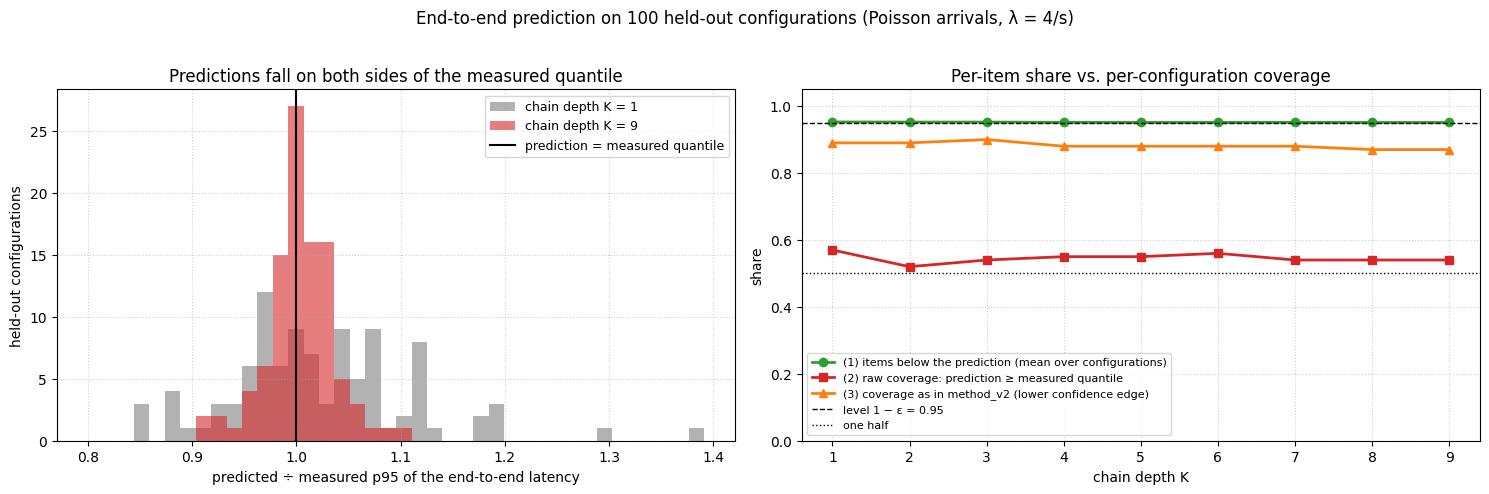

**What this shows** (Poisson arrivals, λ = 4/s, 100 held-out configurations, chain depths 1 to 9).
- **Per item, the level is right on average:** between 95.1% and 95.2% of the items lie below the prediction, close to the level 95%. For single configurations at K = 9 this share ranges from 89.7% to 99.6%.
- **Raw coverage is near one half:** between 52% and 57% of the configurations have a prediction at or above the measured quantile.
- **Coverage as counted in `method_v2`** is higher, between 87% and 90%, because underestimates within the simulation noise are not counted. That margin shrinks from 5.8% of the measured quantile at K = 1 to 1.6% at K = 9 (the confidence interval of the measured quantile is relatively narrower for a longer chain), while the median absolute relative error of the prediction goes from 5.0% to 1.9%; the coverage follows the ratio of the two.
- **None of the three reaches a guarantee:** the level 95% is met per item on average, not per configuration.

In [10]:
item_share = np.array([np.mean(test_cumulative[:, :, k] <= composed[:, k][:, None]) for k in range(n_positions)])
raw_coverage = np.mean(composed >= measured, axis=0)
lower_edge = np.column_stack([quantile_with_lower_bound(test_cumulative[:, :, k], 1 - alpha, **coverage_check)[1] for k in range(n_positions)])
lenient_coverage = np.mean(composed >= lower_edge, axis=0)

fig, (ax_ratio, ax_share) = plt.subplots(1, 2, figsize=(15, 4.8))
ratio_bins = np.linspace(min(0.8, (composed / measured).min()), max(1.2, (composed / measured).max()), 41)
for k, color in ((0, "tab:gray"), (n_positions - 1, level_colors[target_name])):
    ax_ratio.hist(composed[:, k] / measured[:, k], bins=ratio_bins, alpha=0.6, color=color, label=f"chain depth K = {k + 1}")
ax_ratio.axvline(1.0, color="black", linewidth=1.5, label="prediction = measured quantile")
ax_ratio.set_xlabel(f"predicted ÷ measured {target_name} of the end-to-end latency")
ax_ratio.set_ylabel("held-out configurations")
ax_ratio.set_title("Predictions fall on both sides of the measured quantile")
ax_ratio.legend(fontsize=9)

ax_share.plot(positions, item_share, "o-", color="tab:green", linewidth=2, label="(1) items below the prediction (mean over configurations)")
ax_share.plot(positions, raw_coverage, "s-", color="tab:red", linewidth=2, label="(2) raw coverage: prediction ≥ measured quantile")
ax_share.plot(positions, lenient_coverage, "^-", color="tab:orange", linewidth=2, label="(3) coverage as in method_v2 (lower confidence edge)")
ax_share.axhline(1 - alpha, color="black", linestyle="--", linewidth=1, label=f"level 1 − ε = {1 - alpha:g}")
ax_share.axhline(0.5, color="black", linestyle=":", linewidth=1, label="one half")
ax_share.set_ylim(0, 1.05)
ax_share.set_xticks(positions)
ax_share.set_xlabel("chain depth K")
ax_share.set_ylabel("share")
ax_share.set_title("Per-item share vs. per-configuration coverage")
ax_share.legend(fontsize=8, loc="lower left")
for ax in (ax_ratio, ax_share):
    ax.grid(True, linestyle=":", alpha=0.6)
plt.suptitle(f"End-to-end prediction on {n_cfg_test} held-out configurations ({arrival_name} arrivals, λ = {arrival_rate:g}/s)", y=1.02)
plt.tight_layout()
plt.show()

per_config_share = np.mean(test_cumulative[:, :, -1] <= composed[:, -1][:, None], axis=1)
margin = np.median((measured - lower_edge) / measured, axis=0)   # relative width of what counts as simulation noise
display(Markdown(
    f"**What this shows** ({arrival_name} arrivals, λ = {arrival_rate:g}/s, {n_cfg_test} held-out configurations, chain depths 1 to {n_positions}).\n"
    f"- **Per item, the level is right on average:** between {item_share.min():.1%} and {item_share.max():.1%} of the items lie below the "
    f"prediction, close to the level {1 - alpha:.0%}. For single configurations at K = {n_positions} this share ranges from "
    f"{per_config_share.min():.1%} to {per_config_share.max():.1%}.\n"
    f"- **Raw coverage is near one half:** between {pct(raw_coverage.min())} and {pct(raw_coverage.max())} of the configurations have a "
    "prediction at or above the measured quantile.\n"
    f"- **Coverage as counted in `method_v2`** is higher, between {pct(lenient_coverage.min())} and {pct(lenient_coverage.max())}, because "
    f"underestimates within the simulation noise are not counted. That margin shrinks from {margin[0]:.1%} of the measured quantile at "
    f"K = 1 to {margin[-1]:.1%} at K = {n_positions} (the confidence interval of the measured quantile is relatively narrower for a longer chain), while the median absolute relative "
    f"error of the prediction goes from {median_abs(error_composed)[0]:.1%} to {median_abs(error_composed)[-1]:.1%}; the coverage follows the ratio of the two.\n"
    f"- **None of the three reaches a guarantee:** the level {1 - alpha:.0%} is met per item on average, not per configuration."))

## Summary

- **What is learned:** per position and quantile level, a regression from (configuration, upstream quantiles) to the
  quantile of the cumulative latency, fitted on runs of the composed chain. Queueing and the dependence between the
  services are never modeled; they are contained in the measured targets.
- **How it is composed:** the models are evaluated along the chain, each one receiving the predicted quantiles of the
  one before it. No rule combines quantiles; the growth of each quantile from position to position is what the models
  have learned.
- **What it needs:** runs of this chain under this workload. The arrival rate is not even an input here, because every
  run uses the same one; a different load or a chain that was never run has no training data.
- **What it gives:** an accurate prediction of the quantile without a side: it is too low for a large share of the
  configurations (Section 6). The bounds of `method_v2` (Sections 6–7) give up accuracy to stay above the true quantile;
  Section 9 of `method_v2` compares both across chain depths.